### Members: Samrajya Neupane (2408842)

## Workshop 2

### Introduction

This report presents a Big Data pipeline developed to analyze and forecast retail sales using the Walmart Recruiting: Store Sales Forecasting dataset. Large retail chains like Walmart experience significant fluctuations in weekly sales due to factors such as seasonal demand, holidays, promotions, and economic conditions. The proposed pipeline focuses on collecting, processing, and analyzing large-scale sales data to identify patterns and build predictive models that estimate future store sales. By leveraging data-driven forecasting techniques, this system aims to help retailers optimize inventory management, improve supply chain decisions, and better plan promotional strategies. Accurate sales predictions ultimately support more efficient operations and enhanced customer satisfaction.

### Step 1: Data Source & Automation

We are using Walmart Recruiting: Store Sales Forecasting Dataset. It includes the following features:

1. Store
2. Dept
3. Weekly_Sales
4. IsHoliday
5. Type
6. Size
7. Fuel_Price
8. Temperature
9. CPI
10. Unemployment

To automate the acquisition of this dataset, we've connected to the kaggle API and directly imported the zip in our collab space. We then extracted the zip files and processed them as needed. So ultimately, this PoC automation binges on the hope that the author consistently updates the dataset for an accurate representation of the relevant data.

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/BD/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)


In [ ]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting

  0% 0.00/2.70M [00:00<?, ?B/s]
100% 2.70M/2.70M [00:00<00:00, 191MB/s]


In [ ]:
!unzip walmart-recruiting-store-sales-forecasting.zip

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [ ]:
!unzip features.csv.zip
!unzip test.csv.zip
!unzip train.csv.zip

Archive:  features.csv.zip
  inflating: features.csv            
Archive:  test.csv.zip
  inflating: test.csv                
Archive:  train.csv.zip
  inflating: train.csv               


### Step 2: Data Exploration & Transformation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

train = pd.read_csv('train.csv', parse_dates=['Date'])
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv', parse_dates=['Date'])

df = train.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date'], suffixes=('', '_feat'))

markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)
df.dropna(subset=['Weekly_Sales'], inplace=True)
df = df[df['Weekly_Sales'] >= 0]

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Stores: {df['Store'].nunique()} | Departments: {df['Dept'].nunique()}")

Dataset shape: (420285, 17)
Date range: 2010-02-05 00:00:00 → 2012-10-26 00:00:00
Stores: 45 | Departments: 81


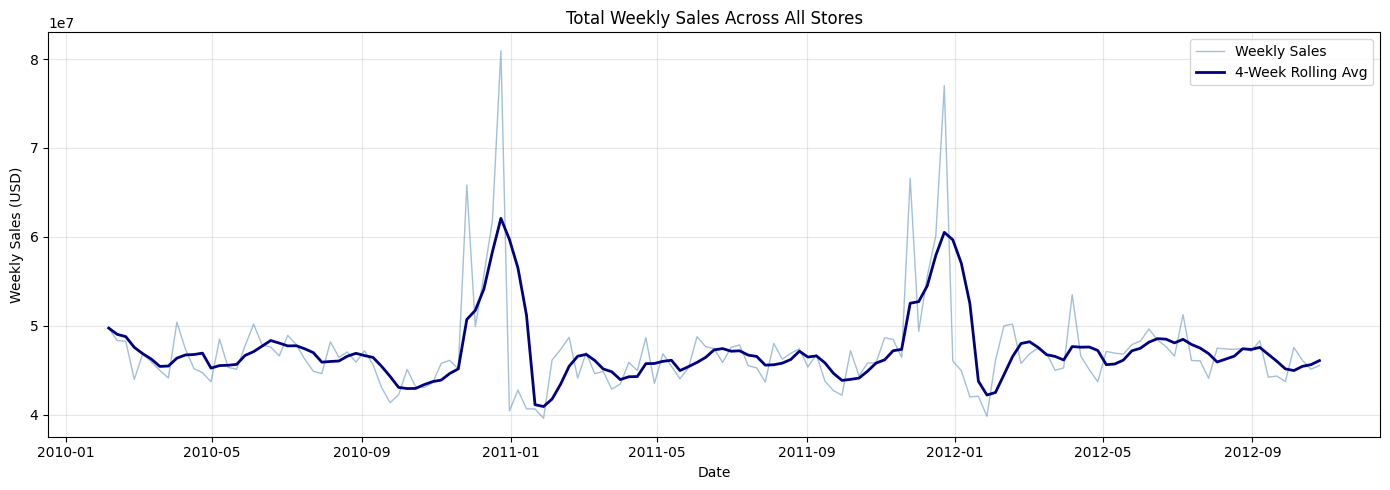

In [ ]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_total['Rolling_4W'] = weekly_total['Weekly_Sales'].rolling(4, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'],
         color='steelblue', linewidth=1, alpha=0.5, label='Weekly Sales')
plt.plot(weekly_total['Date'], weekly_total['Rolling_4W'],
         color='navy', linewidth=2, label='4-Week Rolling Avg')
plt.title('Total Weekly Sales Across All Stores')
plt.ylabel('Weekly Sales (USD)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis of Total Weekly Sales Across All Stores

This line chart displays the total weekly sales for all stores over time, along with a 4-week rolling average:
*   **Clear Seasonal Spikes:** The chart clearly shows significant spikes in total weekly sales, particularly around late November and December each year. These peaks, which reach above 80 million, correspond to major holiday shopping periods like Thanksgiving and Christmas.
*   **Typical Sales Range:** Outside of these holiday peaks, weekly sales generally fluctuate between approximately 43 million and 50 million.
*   **4-Week Rolling Average:** The 4-week rolling average line helps to smooth out short-term fluctuations, making the underlying trend more apparent. It confirms the consistent upward trend during holiday seasons and highlights the general stability of sales during non-peak periods. This smoothing helps in identifying more consistent trends for forecasting.

Non-holiday avg : $15,950
Holiday avg     : $17,093
Holiday premium : +7.2%


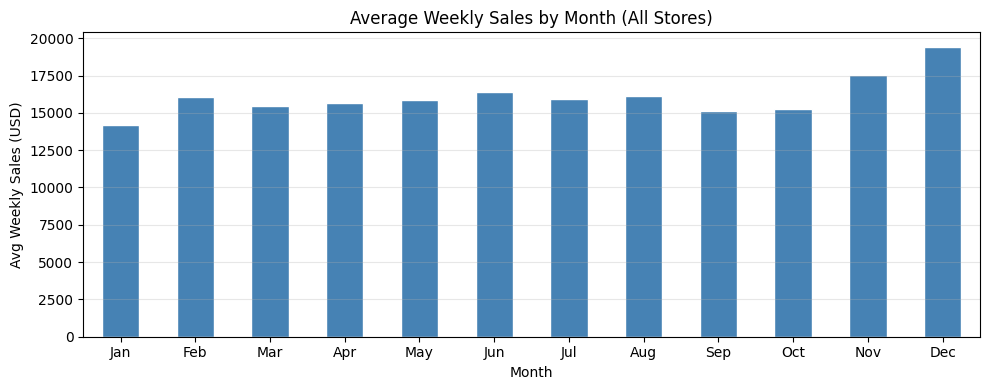

In [ ]:
# Holiday vs non-holiday average
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean()
premium = ((holiday_avg[True] / holiday_avg[False]) - 1) * 100
print(f"Non-holiday avg : ${holiday_avg[False]:,.0f}")
print(f"Holiday avg     : ${holiday_avg[True]:,.0f}")
print(f"Holiday premium : +{premium:.1f}%")

# Sales by month to show seasonality
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10, 4))
monthly_avg.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Weekly Sales by Month (All Stores)')
plt.xlabel('Month')
plt.ylabel('Avg Weekly Sales (USD)')
plt.xticks(ticks=range(12),
           labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
           rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis of Average Weekly Sales by Month (All Stores)

This bar chart illustrates the average weekly sales across all stores for each month of the year:
*   **Strong Year-End Seasonality:** Sales progressively increase towards the end of the year, with a significant peak in November and December. December shows the highest average weekly sales, confirming the strong influence of holiday shopping on retail performance.

*   **Mid-Year Stability:** Months like June, July, and August show relatively stable, higher-than-average sales compared to the beginning and middle of the year, possibly due to summer holidays or specific seasonal product demands.

*   **Early Year Trough:** Sales are generally lower in the early months of the year (January, February), indicating a post-holiday slowdown. February shows a slight rebound from January, which could be attributed to Valentine's Day or other early-year promotions.

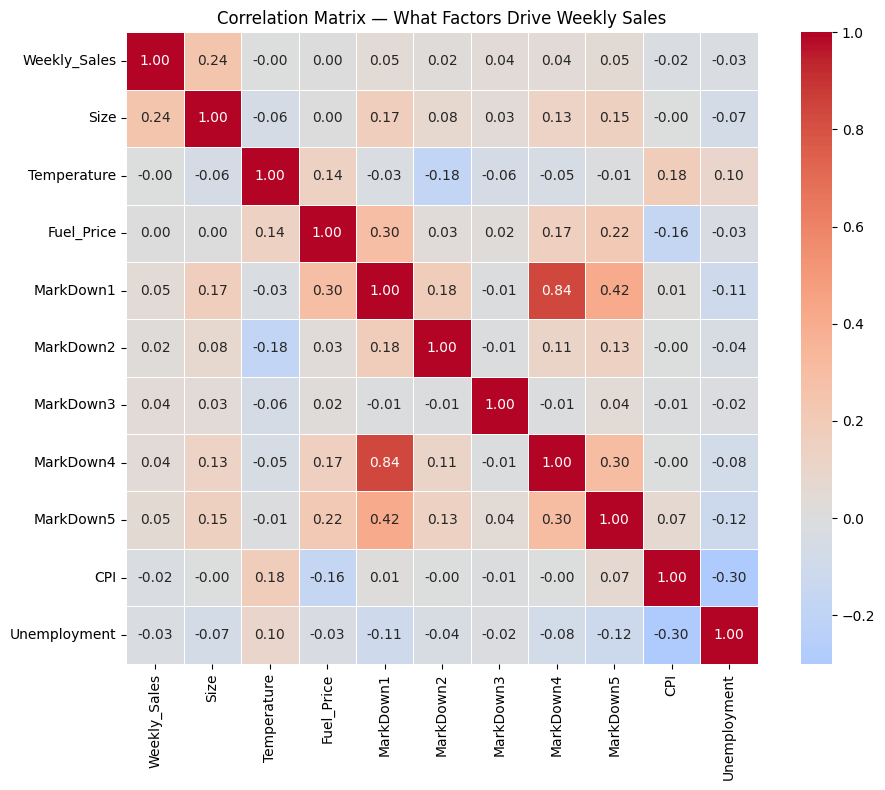

In [ ]:
import seaborn as sns

corr_cols = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price',
             'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
             'CPI', 'Unemployment']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — What Factors Drive Weekly Sales')
plt.tight_layout()
plt.show()

### Analysis of Correlation Matrix

This heatmap illustrates the correlation between 'Weekly_Sales' and other features:
*   **Key Positive Correlations:** 'Weekly_Sales' shows a moderate positive correlation with 'Size' (0.24) and notable positive correlations with 'MarkDown1', 'MarkDown3', and 'MarkDown5', indicating larger stores and certain promotions boost sales.

*   **Weak Influence:** 'Temperature', 'Fuel_Price', 'CPI', and 'Unemployment' have very weak, near-zero correlations with weekly sales, suggesting they are not strong linear drivers in this dataset.

*   **Markdown Interdependency:** MarkDown features often correlate strongly with each other, implying they might be applied together or are interdependent.

/tmp/ipykernel_1932/2506232543.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Weekly_Sales',


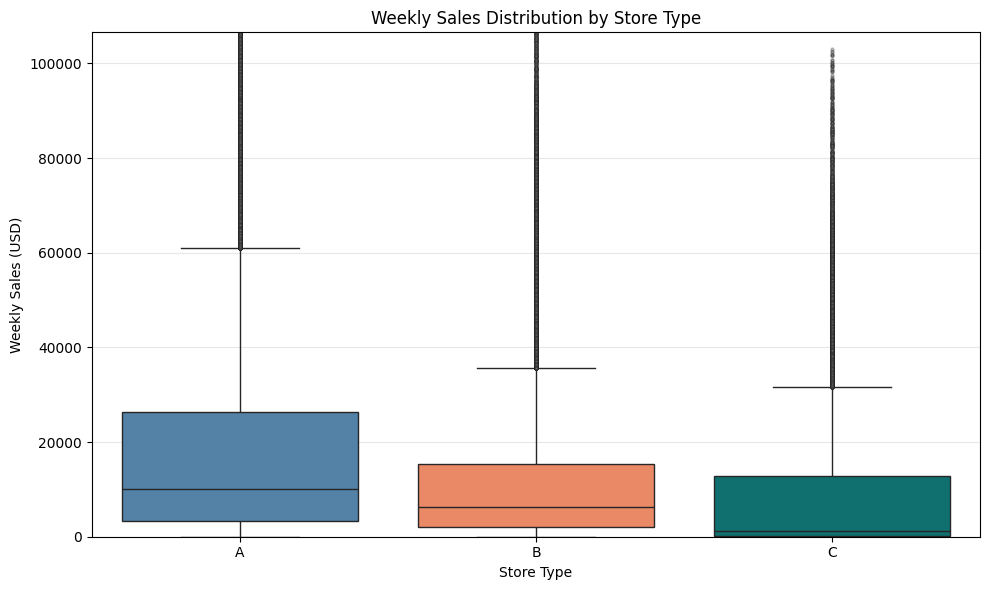

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Type', y='Weekly_Sales',
            palette={'A':'steelblue','B':'coral','C':'teal'},
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3))
plt.title('Weekly Sales Distribution by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales (USD)')
plt.ylim(0, df['Weekly_Sales'].quantile(0.99))  # trim extreme outliers for readability
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis of Weekly Sales Distribution by Store Type

This box plot illustrates the distribution of weekly sales across different store types (A, B, C):
*   **Type A Dominance:** Type A stores consistently exhibit the highest median weekly sales and the broadest range of sales, indicating they are generally the highest-performing and most variable in sales.
*   **Type B Performance:** Type B stores have significantly lower median sales than Type A but higher than Type C, with a narrower sales distribution.
*   **Type C Performance:** Type C stores show the lowest median weekly sales and the tightest sales distribution, suggesting they are the smallest in terms of sales volume and have less variability.

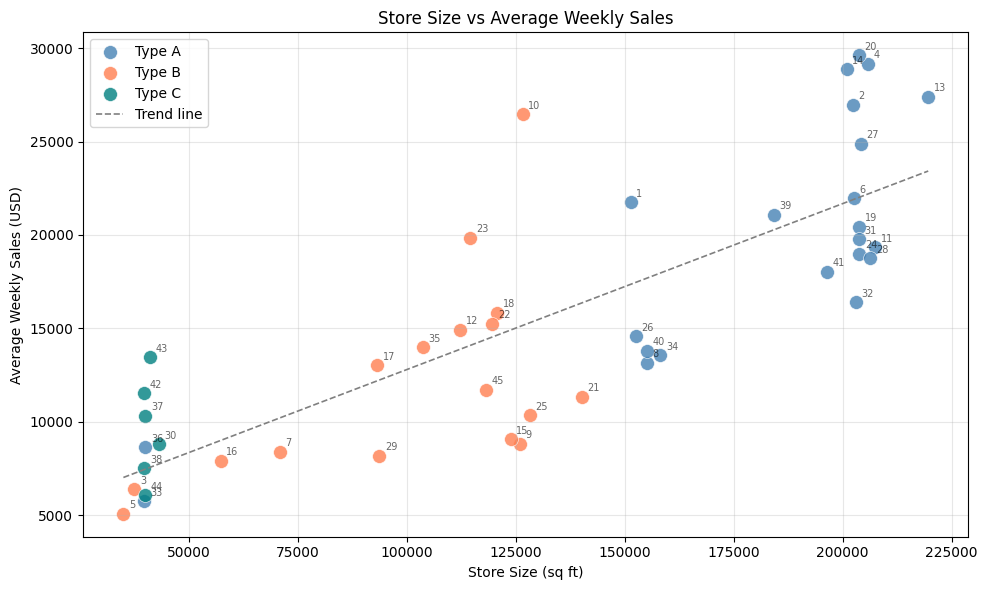

In [ ]:
store_summary = df.groupby('Store').agg(
    Avg_Sales=('Weekly_Sales', 'mean'),
    Total_Sales=('Weekly_Sales', 'sum'),
    Size=('Size', 'first'),
    Type=('Type', 'first')
).reset_index()

colors = {'A': 'steelblue', 'B': 'coral', 'C': 'teal'}

plt.figure(figsize=(10, 6))
for stype, group in store_summary.groupby('Type'):
    plt.scatter(group['Size'], group['Avg_Sales'],
                label=f'Type {stype}', color=colors[stype],
                s=100, alpha=0.8, edgecolors='white', linewidth=0.5)
    # label each store number
    for _, row in group.iterrows():
        plt.annotate(str(int(row['Store'])),
                     (row['Size'], row['Avg_Sales']),
                     fontsize=7, alpha=0.6,
                     xytext=(4, 4), textcoords='offset points')

# trend line
z = np.polyfit(store_summary['Size'], store_summary['Avg_Sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(store_summary['Size'].min(), store_summary['Size'].max(), 100)
plt.plot(x_line, p(x_line), '--', color='gray', linewidth=1.2, label='Trend line')

plt.title('Store Size vs Average Weekly Sales')
plt.xlabel('Store Size (sq ft)')
plt.ylabel('Average Weekly Sales (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis of Store Size vs Average Weekly Sales

The scatter plot and trend line demonstrate a clear relationship between store size and average weekly sales:
*   **Positive Trend:** There is a general positive linear trend, meaning larger stores tend to generate higher average weekly sales. This relationship is visually supported by the upward-sloping trend line.
*   **Store Type Clustering:** The plot also shows that store types tend to cluster: Type A stores are generally larger and have higher average sales, Type B stores are mid-sized with moderate sales, and Type C stores are smaller with lower sales, reinforcing the observations from the store type distribution plot.
*   **Variability:** While a general trend exists, there's still notable variability within each store type and size, indicating other factors beyond just size influence sales performance.

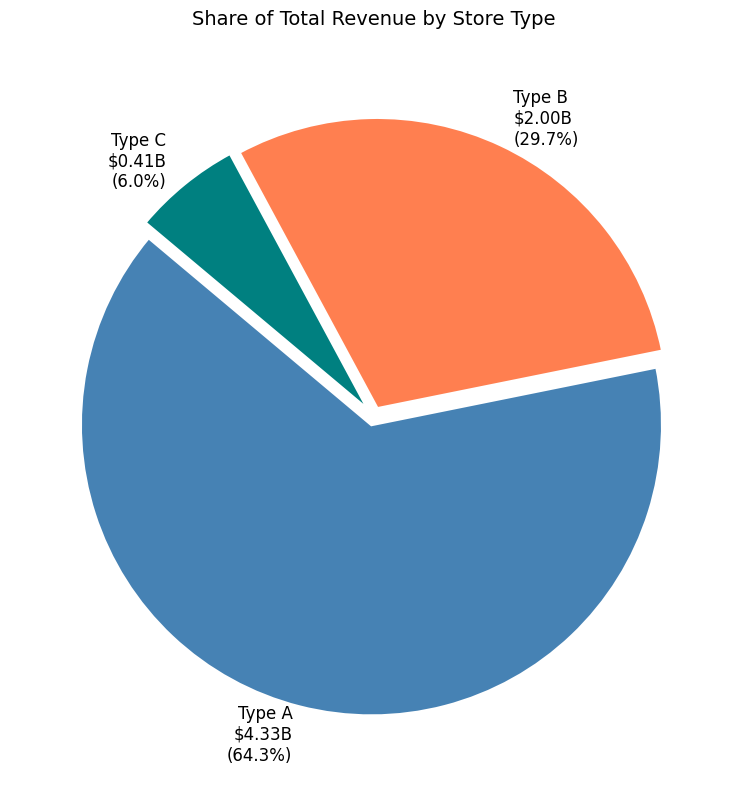


Total revenue across all stores: $6.74B


In [ ]:
type_revenue = df.groupby('Type')['Weekly_Sales'].sum()
total = type_revenue.sum()

labels = [f"Type {t}\n${v/1e9:.2f}B\n({v/total*100:.1f}%)"
          for t, v in type_revenue.items()]
colors_pie = ['steelblue', 'coral', 'teal']
explode = [0.03] * len(type_revenue)  # slight separation for all slices

plt.figure(figsize=(8, 8))
plt.pie(type_revenue, labels=labels, colors=colors_pie, explode=explode,
        startangle=140, textprops={'fontsize': 12},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Share of Total Revenue by Store Type', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print(f"\nTotal revenue across all stores: ${total/1e9:.2f}B")

### Analysis of Share of Total Revenue by Store Type

The pie chart clearly illustrates the contribution of each store type to the total revenue:
*   **Type A Dominance:** Type A stores are the primary revenue drivers, accounting for approximately 64.3% (4.33 Billion) of the total revenue.

*   **Type B Contribution:** Type B stores contribute a substantial 29.7% (2.00 Billion) to the total revenue.

*   **Type C Minor Role:** Type C stores have the smallest share, contributing only 6.0% (0.41 Billion) of the total revenue. This distribution aligns with the sales performance observed in the box plot and size-sales scatter plot.

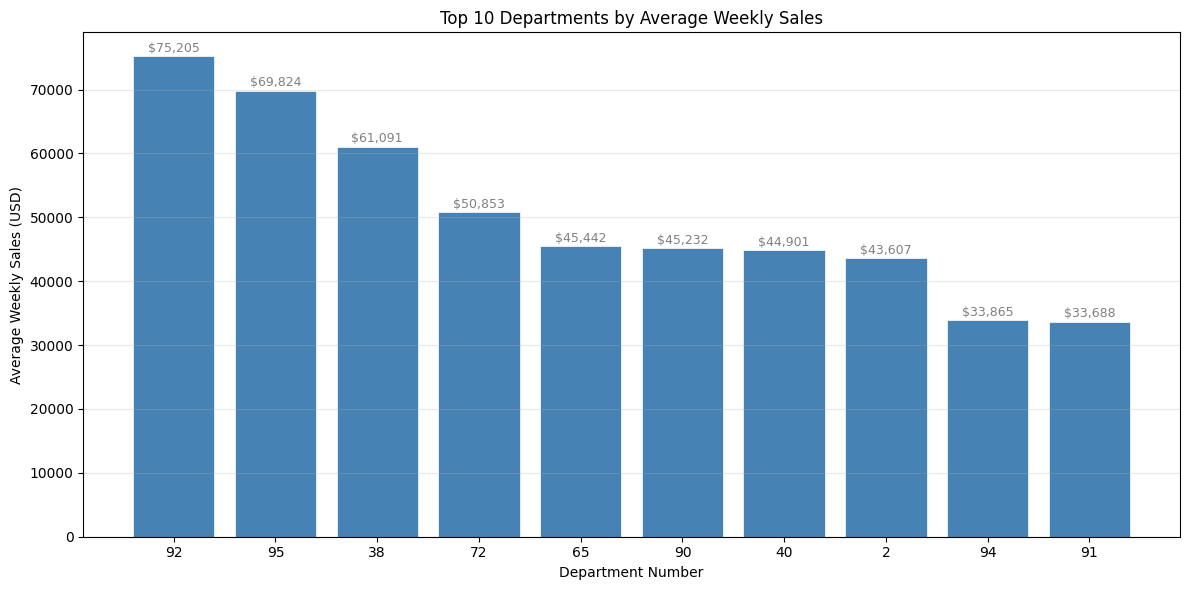

In [ ]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(dept_sales.index.astype(str), dept_sales.values,
               color='steelblue', edgecolor='white', linewidth=0.5)

# value labels on top of each bar
for bar, val in zip(bars, dept_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=9, color='gray')

plt.title('Top 10 Departments by Average Weekly Sales')
plt.xlabel('Department Number')
plt.ylabel('Average Weekly Sales (USD)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis of Top 10 Departments by Average Weekly Sales

The bar chart highlights the departments with the highest average weekly sales:
*   **High-Performing Departments:** Departments 92, 95, and 38 stand out as the top three, consistently generating the highest average weekly sales, with Department 92 leading at approximately $75,205.

*   **Sales Disparity:** There is a significant drop-off in average sales after the top few departments, indicating that a small number of departments contribute disproportionately to the overall sales figures. This suggests opportunities for focused inventory management or promotional strategies.

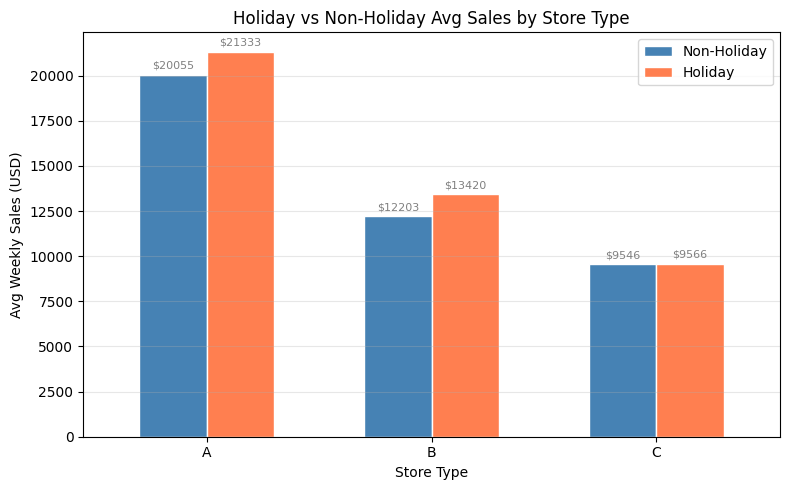

In [ ]:
holiday_type = df.groupby(['Type', 'IsHoliday'])['Weekly_Sales'].mean().unstack()
holiday_type.columns = ['Non-Holiday', 'Holiday']

ax = holiday_type.plot(kind='bar', figsize=(8, 5),
                        color=['steelblue', 'coral'], edgecolor='white', width=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3, fontsize=8, color='gray')

plt.title('Holiday vs Non-Holiday Avg Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Avg Weekly Sales (USD)')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis of Holiday vs Non-Holiday Avg Sales by Store Type

This bar chart compares average weekly sales during holiday and non-holiday periods for each store type:

*   **Holiday Boost for All Types:** All store types experience an increase in average weekly sales during holiday periods compared to non-holiday periods.

*   **Type A and B Significant Boost:** Type A and Type B stores show a noticeable increase in sales during holidays, with Type A having the largest absolute increase in average sales from ~20,055 to ~21,333.

*   **Type C Minimal Impact:** Type C stores show only a marginal increase in sales during holidays (~9,546 to ~9,565), indicating that holidays have a much smaller impact on their sales performance compared to Type A and B stores.

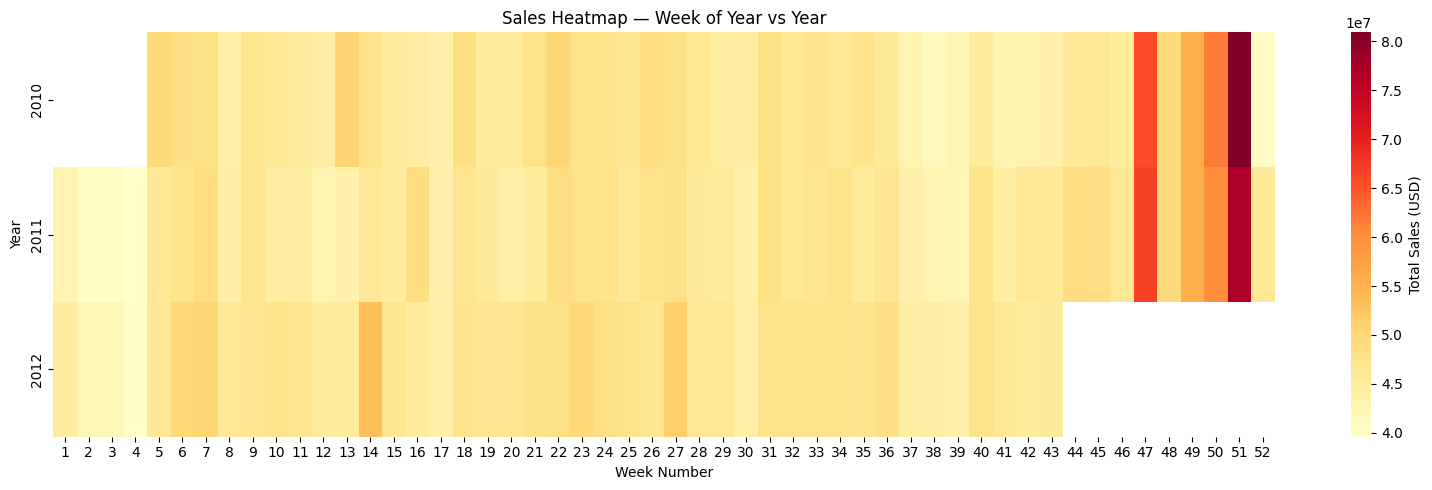

In [ ]:
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

pivot = df.groupby(['Year', 'Week'])['Weekly_Sales'].sum().unstack(level=0)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot.T, cmap='YlOrRd', linewidths=0,
            cbar_kws={'label': 'Total Sales (USD)'})
plt.title('Sales Heatmap — Week of Year vs Year')
plt.xlabel('Week Number')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

### Analysis of Sales Heatmap — Week of Year vs Year

The heatmap visualizes total weekly sales across different weeks of the year and over different years:
*   **Strong Seasonality:** A clear seasonal pattern is evident, with sales consistently peaking towards the end of the year, particularly from week 45 through week 52. This period likely corresponds to major holiday shopping seasons like Thanksgiving and Christmas.

*   **Year-over-Year Growth:** There appears to be a general increase in sales volume from 2010 to 2011, and then again from 2011 to 2012, indicating overall business growth or increased customer activity over the observed period.

*   **Consistent Troughs:** The beginning of the year and mid-year periods generally show lower sales across all years, representing typical off-peak seasons.  

Total weeks analysed : 143
Anomalous weeks found: 5

      Date  Weekly_Sales  Z_Score
2010-11-26   65821216.26 3.436191
2010-12-17   61821317.85 2.701478
2010-12-24   80931586.20 6.211710
2011-11-25   66593835.85 3.578108
2011-12-23   76999773.57 5.489502


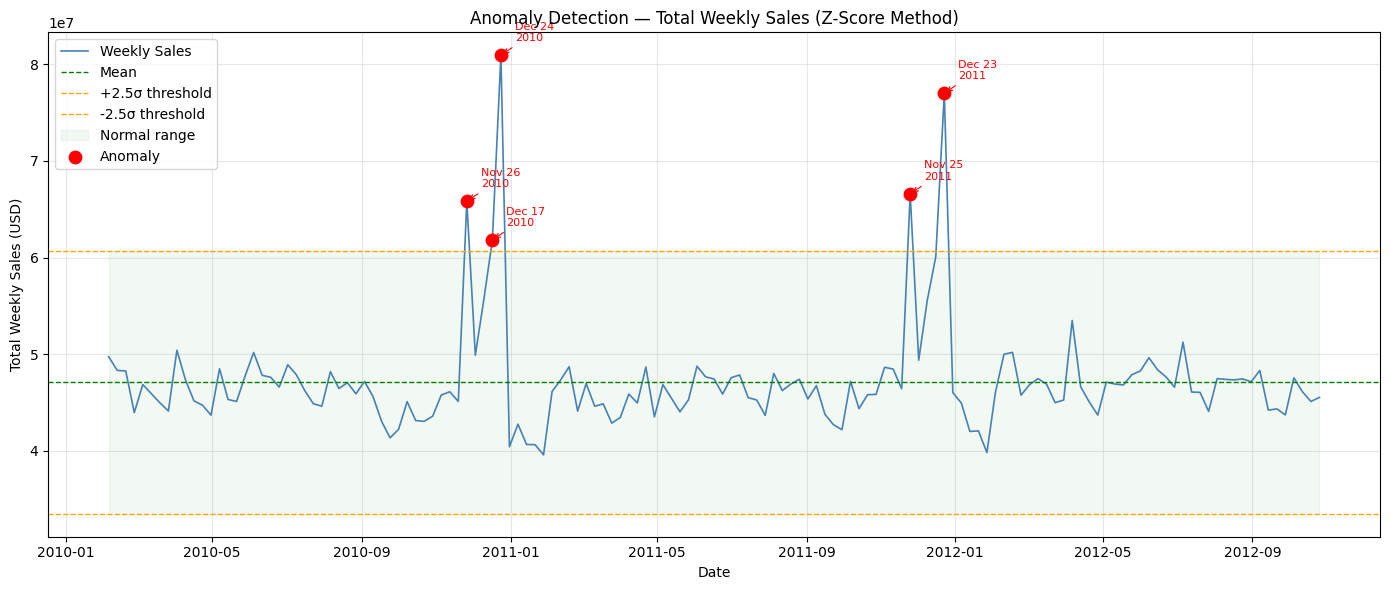

In [ ]:
# Anomaly Detection — Z-Score Method on Total Weekly Sales

weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

mean_s = weekly_total['Weekly_Sales'].mean()
std_s  = weekly_total['Weekly_Sales'].std()

weekly_total['Z_Score'] = (weekly_total['Weekly_Sales'] - mean_s) / std_s
anomalies = weekly_total[weekly_total['Z_Score'].abs() > 2.5]

print(f"Total weeks analysed : {len(weekly_total)}")
print(f"Anomalous weeks found: {len(anomalies)}")
print()
print(anomalies[['Date','Weekly_Sales','Z_Score']].to_string(index=False))

plt.figure(figsize=(14, 6))

# Main sales line
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'],
         color='steelblue', linewidth=1.2, label='Weekly Sales')

# Threshold bands
plt.axhline(mean_s,              color='green',  linestyle='--', linewidth=1,   label='Mean')
plt.axhline(mean_s + 2.5*std_s,  color='orange', linestyle='--', linewidth=1,   label='+2.5σ threshold')
plt.axhline(mean_s - 2.5*std_s,  color='orange', linestyle='--', linewidth=1,   label='-2.5σ threshold')

# Shaded normal band
plt.fill_between(weekly_total['Date'],
                 mean_s - 2.5*std_s,
                 mean_s + 2.5*std_s,
                 color='green', alpha=0.05, label='Normal range')

# Anomaly points
plt.scatter(anomalies['Date'], anomalies['Weekly_Sales'],
            color='red', zorder=5, s=80, label='Anomaly')

# Annotate each anomaly with its date
for _, row in anomalies.iterrows():
    plt.annotate(row['Date'].strftime('%b %d\n%Y'),
                 xy=(row['Date'], row['Weekly_Sales']),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=8, color='red',
                 arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

plt.title('Anomaly Detection — Total Weekly Sales (Z-Score Method)')
plt.ylabel('Total Weekly Sales (USD)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis of Anomaly Detection on Total Weekly Sales

The Z-Score method was applied to identify statistically significant anomalies in total weekly sales:
*   **Identified Anomalies:** Five weeks were identified as anomalous, all showing sales significantly above the mean (Z-Score > 2.5 standard deviations).

*   **Holiday Concentration:** All detected anomalies occur around major holiday periods, specifically in late November (Thanksgiving) and December (Christmas) for both 2010 and 2011. The highest anomaly was on 2010-12-24 with a Z-Score of 6.21.

*   **Expected Spikes:** These anomalies are not necessarily 'errors' but rather expected and significant spikes due to seasonal shopping trends, confirming the strong impact of holidays on retail sales.